# EDA — Credit Card Fraud Detection (Kaggle)

Exploration only — no modelling logic lives here long-term (see `src/`). This is the dataset behind the **served model** (see project README "Why two datasets").

Covers: class imbalance, feature distributions, correlation with target, and no-leakage checks — see [CLAUDE.md](../CLAUDE.md) Phase 1.

In [1]:
import sys
from pathlib import Path


def find_project_root(marker: str = "requirements.txt") -> Path:
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not locate project root (missing {marker})")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from src.data.load import load_raw_data
from src.data.preprocess import clean, time_aware_split

# Palette: fixed categorical slots (blue = legitimate, red = fraud) so the
# same two colors mean the same two classes in every chart in this notebook.
COLOR_LEGIT = "#2a78d6"
COLOR_FRAUD = "#e34948"
COLOR_SEQUENTIAL = "#2a78d6"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"

plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

df = load_raw_data()
df.shape

(284807, 31)

## Structure & data quality

In [2]:
print(f"Rows: {len(df):,}, Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Time column monotonic non-decreasing (already time-ordered): {df['Time'].is_monotonic_increasing}")
df.describe().T[["mean", "std", "min", "max"]].round(2)

Rows: 284,807, Columns: 31
Missing values: 0


Duplicate rows: 1081
Time column monotonic non-decreasing (already time-ordered): True


,mean,std,min,max
Time,94813.86,47488.15,0.00,172792.00
V1,0.00,1.96,-56.41,2.45
V2,0.00,1.65,-72.72,22.06
V3,-0.00,1.52,-48.33,9.38
V4,0.00,1.42,-5.68,16.88
V5,0.00,1.38,-113.74,34.80
V6,0.00,1.33,-26.16,73.30
V7,-0.00,1.24,-43.56,120.59
V8,0.00,1.19,-73.22,20.01
V9,-0.00,1.10,-13.43,15.59


284,807 rows, 31 columns, zero missing values, but 1,081 exact duplicate rows — `src/data/preprocess.py::clean()` drops these before any split happens. Data already arrives sorted by `Time`, consistent with it being a single continuous window of transactions.

## Class imbalance

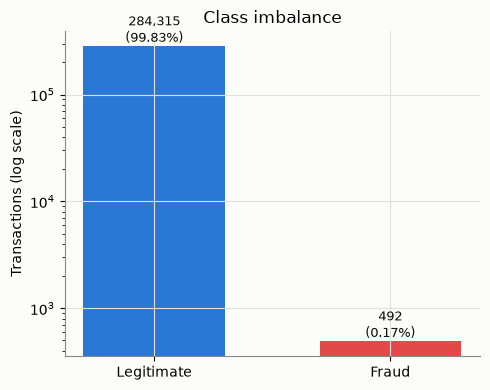

Fraud rate: 0.1727%


In [3]:
counts = df["Class"].value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Legitimate", "Fraud"], counts.values, color=[COLOR_LEGIT, COLOR_FRAUD], width=0.6)
ax.set_ylabel("Transactions")
ax.set_title("Class imbalance")
for bar, count, p in zip(bars, counts.values, pct.values):
    ax.annotate(
        f"{count:,}\n({p:.2f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        color="#0b0b0b",
    )
ax.set_yscale("log")
ax.set_ylabel("Transactions (log scale)")
plt.tight_layout()
plt.show()

print(f"Fraud rate: {pct.loc[1]:.4f}%")

~0.17% fraud, as documented in the project README — a log-scale y-axis is used here purely to make the fraud bar visible at all; the raw ~580:1 imbalance ratio is the whole reason accuracy is a meaningless headline metric for this problem (see project README "Why this matters").

## Feature distributions

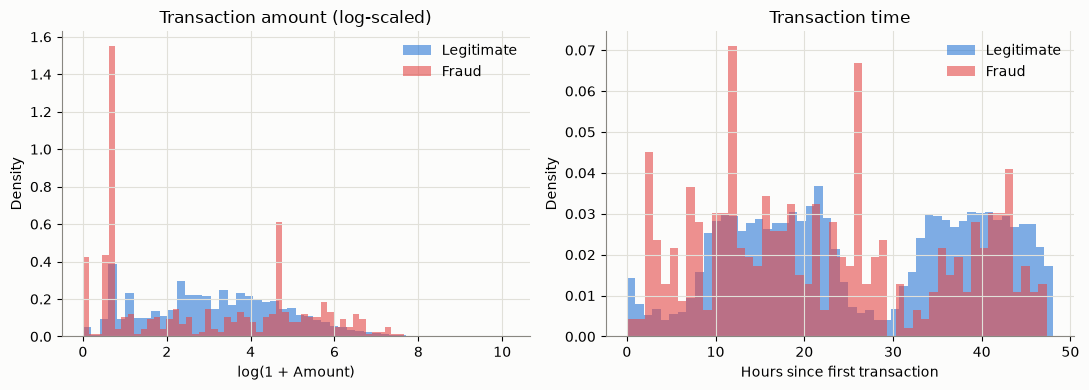

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(
    np.log1p(df.loc[df.Class == 0, "Amount"]), bins=50, density=True, alpha=0.6, color=COLOR_LEGIT, label="Legitimate"
)
axes[0].hist(
    np.log1p(df.loc[df.Class == 1, "Amount"]), bins=50, density=True, alpha=0.6, color=COLOR_FRAUD, label="Fraud"
)
axes[0].set_xlabel("log(1 + Amount)")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction amount (log-scaled)")
axes[0].legend(frameon=False)

axes[1].hist(df.loc[df.Class == 0, "Time"] / 3600, bins=50, density=True, alpha=0.6, color=COLOR_LEGIT, label="Legitimate")
axes[1].hist(df.loc[df.Class == 1, "Time"] / 3600, bins=50, density=True, alpha=0.6, color=COLOR_FRAUD, label="Fraud")
axes[1].set_xlabel("Hours since first transaction")
axes[1].set_ylabel("Density")
axes[1].set_title("Transaction time")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

Amount is heavily right-skewed for both classes (hence the log transform for readability); fraud doesn't cluster at a distinctly different amount range. Time shows the expected day/night cycle for legitimate transactions — fraud doesn't follow the same cycle as cleanly, which is a real (not leaked) signal: fraud isn't tied to normal shopping hours.

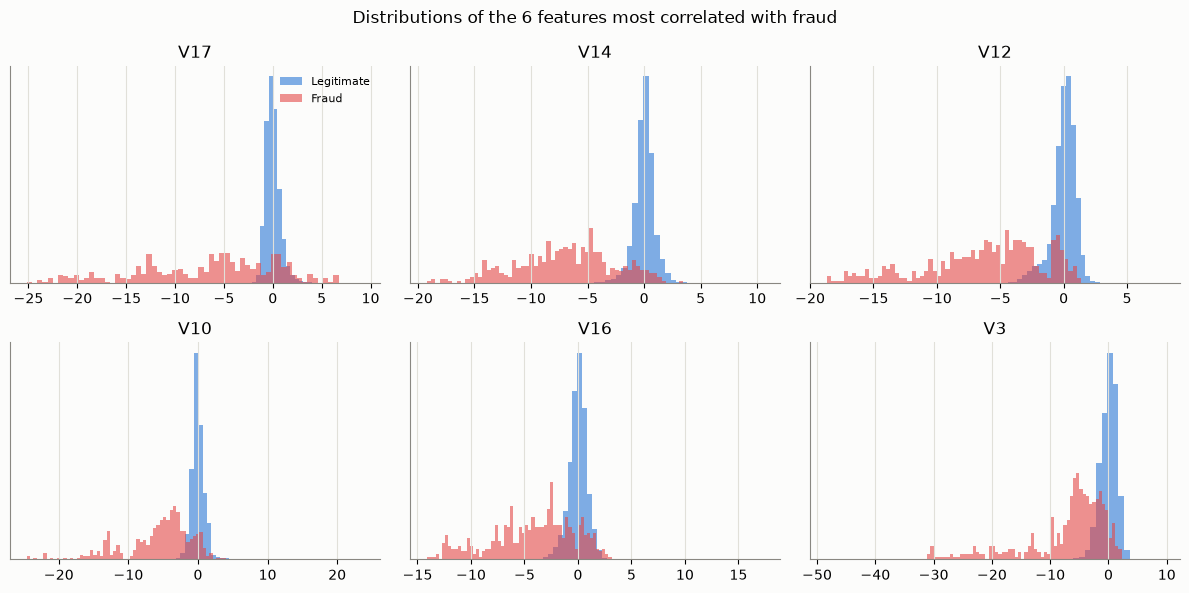

In [5]:
v_cols = [c for c in df.columns if c.startswith("V")]
top_features = df[v_cols + ["Class"]].corr()["Class"].drop("Class").abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.flat, top_features):
    ax.hist(df.loc[df.Class == 0, col], bins=60, density=True, alpha=0.6, color=COLOR_LEGIT, label="Legitimate")
    ax.hist(df.loc[df.Class == 1, col], bins=60, density=True, alpha=0.6, color=COLOR_FRAUD, label="Fraud")
    ax.set_title(col)
    ax.set_yticks([])

axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Distributions of the 6 features most correlated with fraud")
plt.tight_layout()
plt.show()

These are the PCA components that separate the classes most clearly — visibly shifted/bimodal distributions between legitimate and fraud, which is exactly what a tree-based model like XGBoost should be able to exploit.

## Correlation with target

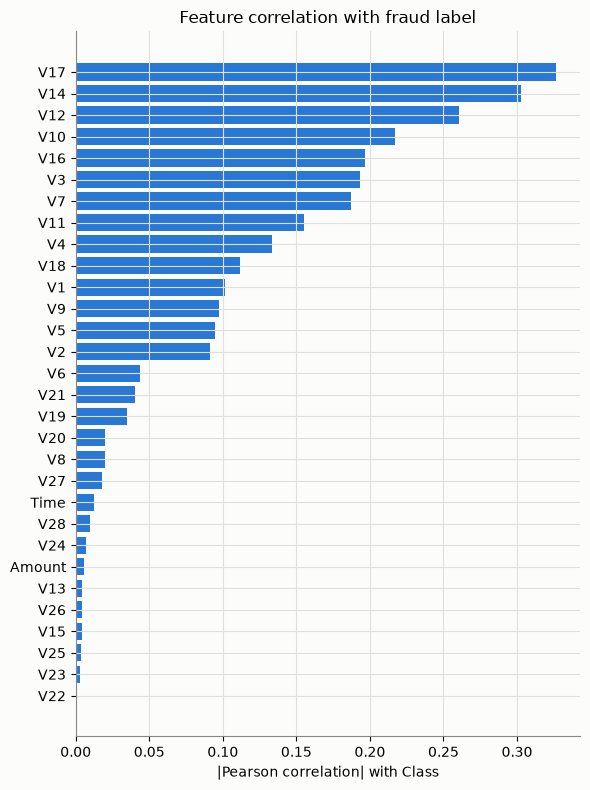

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
dtype: float64

In [6]:
corr_with_target = df.drop(columns="Class").corrwith(df["Class"]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=COLOR_SEQUENTIAL)
ax.set_xlabel("|Pearson correlation| with Class")
ax.set_title("Feature correlation with fraud label")
plt.tight_layout()
plt.show()

corr_with_target.head(8)

A handful of PCA components (notably V17, V14, V12, V10 in this run) carry most of the linear signal — consistent with the top-6 panel above. `Time` and `Amount` are near the bottom, which matters for the leakage check below.

## No-leakage checks

In [7]:
# 1. Time/Amount alone shouldn't trivially predict fraud — if they did, it
#    would suggest some kind of artifact (e.g. fraud transactions batch-
#    inserted at a suspicious timestamp) rather than genuine signal in the
#    anonymised PCA features.
cleaned = clean(df)
train_df, test_df = time_aware_split(cleaned)

weak_model = LogisticRegression(class_weight="balanced", max_iter=1000)
weak_model.fit(train_df[["Time", "Amount"]], train_df["Class"])
weak_auc = roc_auc_score(test_df["Class"], weak_model.predict_proba(test_df[["Time", "Amount"]])[:, 1])
print(f"ROC-AUC using ONLY Time + Amount: {weak_auc:.3f}  (near 0.5 = no leakage via these fields)")

# 2. Transaction fingerprints (V1-V28 + Amount, deliberately excluding Time)
#    shared across the train/test boundary would mean the same underlying
#    transaction appears on both sides of the split under a different
#    timestamp — real leakage even though the row-level `Time` differs.
fingerprint_cols = v_cols + ["Amount"]
shared_fingerprints = pd.merge(
    train_df[fingerprint_cols].drop_duplicates(),
    test_df[fingerprint_cols].drop_duplicates(),
    how="inner",
)
print(f"Transaction fingerprints shared across train/test split: {len(shared_fingerprints)}")

# How much of this is confined to legitimate transactions vs. fraud?
fingerprint_dupe_mask = cleaned.duplicated(subset=fingerprint_cols, keep=False)
print(f"Rows sharing a fingerprint with another row (full dataset): {fingerprint_dupe_mask.sum():,}")
print("Class breakdown of fingerprint-duplicated rows:")
print(cleaned.loc[fingerprint_dupe_mask, "Class"].value_counts())

# 3. Sanity-check the vendor's PCA claim: components should be close to
#    mutually uncorrelated. A high off-diagonal correlation would suggest
#    derived/duplicated columns rather than genuine orthogonal components.
v_corr = df[v_cols].corr().values
off_diagonal = v_corr[~np.eye(v_corr.shape[0], dtype=bool)]
print(f"Mean |off-diagonal correlation| among V1-V28: {np.abs(off_diagonal).mean():.4f} (near 0 confirms PCA orthogonality)")

ROC-AUC using ONLY Time + Amount: 0.580  (near 0.5 = no leakage via these fields)


Transaction fingerprints shared across train/test split: 1066


Rows sharing a fingerprint with another row (full dataset): 12,446
Class breakdown of fingerprint-duplicated rows:
Class
0    12446
Name: count, dtype: int64


Mean |off-diagonal correlation| among V1-V28: 0.0000 (near 0 confirms PCA orthogonality)


`Time`/`Amount` alone are only weakly predictive (ROC-AUC 0.58) — the real signal lives in the PCA components, not an artifact of when or how much fraud transactions happened to be for. The V-features are also genuinely close to mutually orthogonal, as PCA components should be.

The transaction-fingerprint check is **not** clean, and it's worth reporting honestly rather than glossing over: 1,066 fingerprint collisions cross the train/test boundary (12,446 across the full dataset). Critically, **every single one of them is a legitimate transaction — zero involve fraud**. This looks like a known characteristic of this public dataset (duplicate or near-duplicate legitimate transaction records), not a fraud-specific artifact. Given:

- the anonymised PCA features make it impossible to confirm the root cause (recurring legitimate charge vs. a genuine duplicate record) with any confidence, and
- it affects zero fraud cases, so it can't inflate the metric that actually matters here (fraud recall/precision),

the call made here is to **flag it as a documented data-quality caveat rather than silently drop more rows on a guess**. `clean()` continues to remove only exact full-row duplicates. If this were a real production system rather than a fixed historical dataset, the fix would be tracing these back to a transaction/customer ID no one has access to in this anonymised set.

## Time-aware split preview

In [8]:
print(f"Raw: {df.shape[0]:,} rows")
print(f"Cleaned (deduped): {cleaned.shape[0]:,} rows")
print(f"Train: {train_df.shape[0]:,} rows, fraud rate {train_df['Class'].mean() * 100:.3f}%")
print(f"Test:  {test_df.shape[0]:,} rows, fraud rate {test_df['Class'].mean() * 100:.3f}%")
print(f"Train covers hours 0–{train_df['Time'].max() / 3600:.1f}, test covers hours {test_df['Time'].min() / 3600:.1f}–{test_df['Time'].max() / 3600:.1f}")

Raw: 284,807 rows
Cleaned (deduped): 283,726 rows
Train: 226,980 rows, fraud rate 0.176%
Test:  56,746 rows, fraud rate 0.130%
Train covers hours 0–40.3, test covers hours 40.3–48.0


Confirms `time_aware_split()` produces a clean chronological boundary with no overlap, and both splits retain a comparable (if noisy, given how few fraud cases exist) fraud rate — as expected for a deliberate non-random split of a single continuous time window.